In [40]:
import pandas as pd
import numpy as np

path = "WholeYear.csv"
raw = pd.read_csv(path)

# first row to header
new_cols = raw.iloc[0].astype(str).str.strip().tolist()
df = raw.iloc[1:].copy()
df.columns = new_cols
df = df.reset_index(drop=True)

# Parse time
time_col = "Time (LST)"
df[time_col] = pd.to_datetime(df[time_col], errors="coerce", format="%Y-%m-%d %I:%M %p")

# Coerce numeric columns
for c in df.columns:
    if c == time_col: 
        continue
    df[c] = pd.to_numeric(df[c], errors="coerce")

# Drop invalid time, sort, hourly resolution
df = df.dropna(subset=[time_col]).sort_values(time_col).drop_duplicates(subset=[time_col]).reset_index(drop=True)

# Add time features
df["hour"] = df[time_col].dt.hour
df["month"] = df[time_col].dt.month
df["date"] = df[time_col].dt.date

print(df.shape)
print(df.columns.tolist())
print(df.head())


(5087, 30)
['Time (LST)', 'Air Temp (°F)', '0.5 m Air Temp (°F)', '1.5 m Air Temp (°F)', '3 m Air Temp (°F)', 'Relative Humidity (%)', 'Precipitation (in)', 'Accumulated Precip (in)', 'Solar Radiation (W / m²)', 'Wind Speed (mph)', 'Wind Direction (°)', 'Wind Gust (mph)', '4" Bare Soil Temp (°F)', '4" Grass Soil Temp (°F)', '2" Soil Temp (°F)', '2" Soil Water Content (%)', '4" Soil Temp (°F)', '4" Soil Water Content (%)', '8" Soil Temp (°F)', '8" Soil Water Content (%)', '20" Soil Temp (°F)', '20" Soil Water Content (%)', 'Inversion Strength', 'Max Inversion', 'Heat Index (°F)', 'Wind Chill (°F)', 'Barometric Pressure (in Hg)', 'hour', 'month', 'date']
           Time (LST)  Air Temp (°F)  0.5 m Air Temp (°F)  \
0 2025-01-31 19:00:00           38.1                 38.1   
1 2025-01-31 20:00:00           36.3                 36.4   
2 2025-01-31 21:00:00           35.1                 35.3   
3 2025-01-31 22:00:00           34.6                 34.7   
4 2025-01-31 23:00:00           33

In [41]:
target = '20" Soil Temp (°F)'  #response variable
# Drop columns that are entirely missing
df = df.dropna(axis=1, how="all")

# Keep rows where target exists
df = df.dropna(subset=[target]).copy()


Missing % top:
 Heat Index (°F)             86.63
Wind Chill (°F)             72.83
1.5 m Air Temp (°F)          2.02
3 m Air Temp (°F)            2.02
0.5 m Air Temp (°F)          2.02
Max Inversion                2.02
4" Grass Soil Temp (°F)      2.02
4" Bare Soil Temp (°F)       2.02
Inversion Strength           2.02
Relative Humidity (%)        1.18
Air Temp (°F)                1.18
Solar Radiation (W / m²)     0.65
Wind Gust (mph)              0.43
Wind Speed (mph)             0.43
Accumulated Precip (in)      0.00
dtype: float64


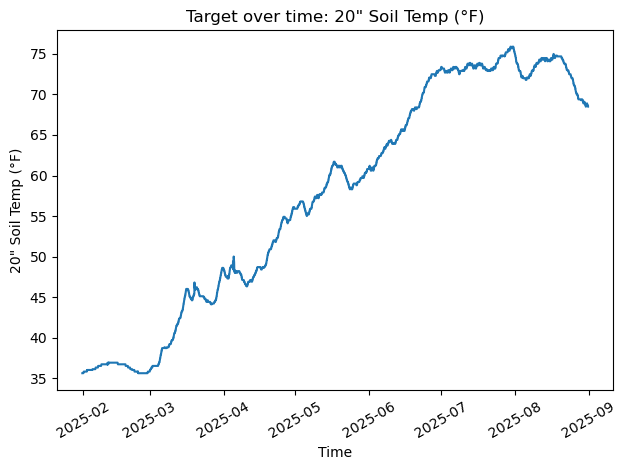


Top correlations with target (abs):
 20" Soil Temp (°F)           1.000000
8" Soil Temp (°F)            0.994630
4" Grass Soil Temp (°F)      0.986832
4" Soil Temp (°F)            0.985367
2" Soil Temp (°F)            0.979650
month                        0.966645
4" Bare Soil Temp (°F)       0.957338
3 m Air Temp (°F)            0.823568
1.5 m Air Temp (°F)          0.818979
Air Temp (°F)                0.818101
0.5 m Air Temp (°F)          0.815372
8" Soil Water Content (%)   -0.593037
Wind Chill (°F)              0.565263
Wind Speed (mph)            -0.424660
Heat Index (°F)              0.422203
Name: 20" Soil Temp (°F), dtype: float64


In [42]:
import matplotlib.pyplot as plt

# missingness
missing = (df.isna().mean().sort_values(ascending=False) * 100).round(2)
print("Missing % top:\n", missing.head(15))

# time series plot of target(response variable)
plt.figure()
plt.plot(df[time_col], df[target])
plt.title(f"Target over time: {target}")
plt.xlabel("Time")
plt.ylabel(target)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# correlations (numeric only)
num = df.select_dtypes(include=[np.number])
corr = num.corr(numeric_only=True)[target].sort_values(key=lambda s: s.abs(), ascending=False)
print("\nTop correlations with target (abs):\n", corr.head(15))


In [43]:
from lingam import VARLiNGAM

# Choosing variables including target and a few strong candidates (non-lagged originals)
# including the ORIGINAL variables (not the lag-expanded columns) for VARLiNGAM, not including soil temperatures at various depths in this.
core = [target]

# Add a few predictor originals that seem relevant in weather/soil context if present
likely = [
    "Air Temp (°F)",
    "0.5 m Air Temp (°F)",
    "1.5 m Air Temp (°F)",
    "3 m Air Temp (°F)",
    "Relative Humidity (%)",
    "Precipitation (in)",
    "Accumulated Precip (in)",
    "Solar Radiation (W / m²)",
    "Wind Speed (mph)",
    "Wind Direction (°)",
    "Wind Gust (mph)",
    "Inversion Strength",
    "Max Inversion",
    "Barometric Pressure (in Hg)"
]
for c in likely:
    if c in df.columns and c != target:
        core.append(c)

# Keep only numeric + drop missing
ts = df[core].dropna().reset_index(drop=True)

# Fit VARLiNGAM (choose lag order; try 1..24 and compare later)
p = 6  # start with 6 hours; try 12/24 too
model = VARLiNGAM(lags=p, criterion=None)  # criterion None = use fixed p
model.fit(ts.values)

# Adjacency matrices:
# model.adjacency_matrices_[0] is instantaneous effects
# model.adjacency_matrices_[k] for lag k effects (k=1..p)
A0 = model.adjacency_matrices_[0]
print("Instantaneous adjacency A0 shape:", A0.shape)

# Map back to variable names
var_names = ts.columns.tolist()


C:\Users\Khushi\anaconda3\Lib\site-packages\lingam\direct_lingam.py:224: RuntimeWarning: invalid value encountered in divide
  xj_std = (X[:, j] - np.mean(X[:, j])) / np.std(X[:, j])
C:\Users\Khushi\anaconda3\Lib\site-packages\lingam\direct_lingam.py:223: RuntimeWarning: invalid value encountered in divide
  xi_std = (X[:, i] - np.mean(X[:, i])) / np.std(X[:, i])
C:\Users\Khushi\anaconda3\Lib\site-packages\lingam\direct_lingam.py:151: RuntimeWarning: invalid value encountered in scalar divide
  return xi - (np.cov(xi, xj, bias=True)[0, 1] / np.var(xj)) * xj
C:\Users\Khushi\anaconda3\Lib\site-packages\sklearn\linear_model\_least_angle.py:723: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, after 7 iterations, i.e. alpha=1.523e-04, with an active set of 7 regressors, and the smallest cholesky pivot element being 2.980e-08. Reduce max_iter or increase eps parameters.
  warnings.warn(
C:\Users\Khushi\anaconda3\Lib\site-packages\sklearn\linear_model\_least_ang

Instantaneous adjacency A0 shape: (14, 14)


In [44]:
target_idx = var_names.index(target)

# Instantaneous causes of target: nonzero column entries into target
inst_parents = [(var_names[i], A0[target_idx, i]) for i in range(len(var_names)) if abs(A0[target_idx, i]) > 1e-6]
inst_parents = sorted(inst_parents, key=lambda x: abs(x[1]), reverse=True)

print("Instantaneous parents of target (name, weight):")
print(inst_parents)

# Lagged causes: look at A_k for k=1..p
lagged = []
for k in range(1, p+1):
    Ak = model.adjacency_matrices_[k]
    for i in range(len(var_names)):
        w = Ak[target_idx, i]
        if abs(w) > 1e-6:
            lagged.append((k, var_names[i], w))

lagged = sorted(lagged, key=lambda x: abs(x[2]), reverse=True)
print("\nTop lagged causes into target (lag, name, weight):")
print(lagged[:30])


Instantaneous parents of target (name, weight):
[]

Top lagged causes into target (lag, name, weight):
[(1, '20" Soil Temp (°F)', np.float64(0.9676979188130503)), (1, 'Accumulated Precip (in)', np.float64(0.27392478722774893)), (3, '20" Soil Temp (°F)', np.float64(0.08059350307689851)), (6, '20" Soil Temp (°F)', np.float64(-0.05016447792344392)), (6, '3 m Air Temp (°F)', np.float64(0.002617687414927138)), (3, '0.5 m Air Temp (°F)', np.float64(-0.0008944027676413533)), (6, 'Max Inversion', np.float64(0.0005264735758567363)), (1, '0.5 m Air Temp (°F)', np.float64(-0.00013465637559951528)), (4, 'Relative Humidity (%)', np.float64(-3.095981536526525e-05)), (4, 'Solar Radiation (W / m²)', np.float64(-2.063525241101194e-05))]


In [45]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error

def mape(y_true, y_pred, eps=1e-8):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    denom = np.maximum(np.abs(y_true), eps)
    return np.mean(np.abs((y_true - y_pred) / denom)) * 100

def make_lagged_selected(df, cols_needed, max_lag):
    
    df2 = df[cols_needed].copy()

    
    df2 = df2.apply(pd.to_numeric, errors="coerce")

    # Build lagged features
    X = pd.concat([df2.shift(l).add_suffix(f"_lag{l}") for l in range(1, max_lag+1)], axis=1)
    y = df2.copy()

    # Drop rows where the target is NaN OR any chosen predictors are NaN
    return X, y

# -----------------------------
# SETTINGS
# -----------------------------
target = '20" Soil Temp (°F)'

causal_lagged = [
    (1, '20" Soil Temp (°F)'),
    (1, 'Accumulated Precip (in)'),
    (3, '20" Soil Temp (°F)'),
    (6, '20" Soil Temp (°F)'),
    (6, '3 m Air Temp (°F)'),
    (3, '0.5 m Air Temp (°F)'),
    (6, 'Max Inversion'),
    (1, '0.5 m Air Temp (°F)'),
    (4, 'Relative Humidity (%)'),
    (4, 'Solar Radiation (W / m²)')   
]

# columns needed in df BEFORE lagging
cols_needed = sorted(set([name for _, name in causal_lagged] + [target]))


df = df.sort_index()

print("Rows in raw df:", len(df))
print("Rows after keeping only needed cols:", len(df[cols_needed]))

# Auto choose max_lag safely
requested_max_lag = 6
max_lag = min(requested_max_lag, max(1, len(df) - 5))  # keep some room
print("Using max_lag =", max_lag)

X_all, Y_all = make_lagged_selected(df, cols_needed, max_lag)

# predictor column list
predictor_cols = []
for lag, name in causal_lagged:
    if lag <= max_lag:
        predictor_cols.append(f"{name}_lag{lag}")

# always include own lags 1..max_lag
for lag in range(1, max_lag+1):
    col = f"{target}_lag{lag}"
    if col not in predictor_cols:
        predictor_cols.append(col)

# Keeping only predictors that exist
predictor_cols = [c for c in predictor_cols if c in X_all.columns]


needed_for_model = predictor_cols + [target]
tmp = pd.concat([X_all[predictor_cols], Y_all[[target]]], axis=1)

print("Rows before dropna (lagged table):", len(tmp))
tmp = tmp.dropna()
print("Rows after dropna:", len(tmp))

if len(tmp) == 0:
    print("\n❌ Still 0 rows after dropna.")
    print("Most likely: your target/predictor columns are non-numeric or mostly missing.")
    print("Try: print(df[cols_needed].head(20)) and df[cols_needed].isna().mean()")
    raise SystemExit

X_all = tmp[predictor_cols]
y_all = tmp[target]

# Train/test split
split = int(len(X_all) * 0.8)
X_train, X_test = X_all.iloc[:split], X_all.iloc[split:]
y_train, y_test = y_all.iloc[:split], y_all.iloc[split:]

print("Train rows:", len(X_train), "Test rows:", len(X_test))

model = Ridge(alpha=1.0)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape_val = mape(y_test, y_pred)

print("\n✅ Forecast metrics (1-step ahead):")
print(f"MAE : {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAPE: {mape_val:.2f}%")


Rows in raw df: 5087
Rows after keeping only needed cols: 5087
Using max_lag = 6
Rows before dropna (lagged table): 5087
Rows after dropna: 4947
Train rows: 3957 Test rows: 990

✅ Forecast metrics (1-step ahead):
MAE : 0.0319
RMSE: 0.0539
MAPE: 0.04%


In [46]:
## Granger method ->obtained predictor variable subset

import numpy as np
import pandas as pd
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error

def mape(y_true, y_pred, eps=1e-8):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    denom = np.maximum(np.abs(y_true), eps)
    return np.mean(np.abs((y_true - y_pred) / denom)) * 100

def make_lagged_selected(df, cols_needed, max_lag):
    # Keeping only needed columns
    df2 = df[cols_needed].copy()

    
    df2 = df2.apply(pd.to_numeric, errors="coerce")

    # Build lagged features
    X = pd.concat([df2.shift(l).add_suffix(f"_lag{l}") for l in range(1, max_lag+1)], axis=1)
    y = df2.copy()

    
    return X, y

# -----------------------------
# SETTINGS
# -----------------------------
target = '20" Soil Temp (°F)'

causal_lagged = [
    (11, 'Air Temp (°F)'),
    (11, '0.5 m Air Temp (°F)'),
    (11,"1.5 m Air Temp (°F)"),
    (11,"3 m Air Temp (°F)"),
    (12,"Relative Humidity (%)"),
    (12,"Solar Radiation (W / m²)"),
    (11,"Wind Speed (mph)"),
    (7,"Wind Direction (°)"),
    (11,"Wind Gust (mph)"),
    (12,'4" Bare Soil Temp (°F)'),
    (12,'4" Grass Soil Temp (°F)'),
    (12,'2" Soil Temp (°F)'),
    (12, '4" Soil Temp (°F)'),
    (7, '4" Soil Water Content (%)'),
    (12,'8" Soil Temp (°F)'),
    (7,"Inversion Strength"),
    (7,"Max Inversion")
]

# columns needed in df BEFORE lagging
cols_needed = sorted(set([name for _, name in causal_lagged] + [target]))


df = df.sort_index()

print("Rows in raw df:", len(df))
print("Rows after keeping only needed cols:", len(df[cols_needed]))


requested_max_lag = 12
max_lag = min(requested_max_lag, max(1, len(df) - 5))  # keep some room
print("Using max_lag =", max_lag)

X_all, Y_all = make_lagged_selected(df, cols_needed, max_lag)

# predictor column list
predictor_cols = []
for lag, name in causal_lagged:
    if lag <= max_lag:
        predictor_cols.append(f"{name}_lag{lag}")

# always include own lags 1..max_lag
for lag in range(1, max_lag+1):
    col = f"{target}_lag{lag}"
    if col not in predictor_cols:
        predictor_cols.append(col)

# Keep only predictors that exist
predictor_cols = [c for c in predictor_cols if c in X_all.columns]


needed_for_model = predictor_cols + [target]
tmp = pd.concat([X_all[predictor_cols], Y_all[[target]]], axis=1)

print("Rows before dropna (lagged table):", len(tmp))
tmp = tmp.dropna()
print("Rows after dropna:", len(tmp))

if len(tmp) == 0:
    print("\n❌ Still 0 rows after dropna.")
    print("Most likely: your target/predictor columns are non-numeric or mostly missing.")
    print("Try: print(df[cols_needed].head(20)) and df[cols_needed].isna().mean()")
    raise SystemExit

X_all = tmp[predictor_cols]
y_all = tmp[target]

# Train/test split
split = int(len(X_all) * 0.8)
X_train, X_test = X_all.iloc[:split], X_all.iloc[split:]
y_train, y_test = y_all.iloc[:split], y_all.iloc[split:]

print("Train rows:", len(X_train), "Test rows:", len(X_test))

model = Ridge(alpha=1.0)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape_val = mape(y_test, y_pred)

print("\n✅ Forecast metrics (1-step ahead):")
print(f"MAE : {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAPE: {mape_val:.2f}%")


Rows in raw df: 5087
Rows after keeping only needed cols: 5087
Using max_lag = 12
Rows before dropna (lagged table): 5087
Rows after dropna: 4947
Train rows: 3957 Test rows: 990

✅ Forecast metrics (1-step ahead):
MAE : 0.0484
RMSE: 0.0618
MAPE: 0.07%


In [47]:

from itertools import combinations
from sklearn.linear_model import LinearRegression
from scipy.stats import f

# -----------------------------
# 0) REQUIREMENTS from previous work
# -----------------------------
# 
#  The cleaned dataframe
# 


target_col = '20" Soil Temp (°F)'  

# Parents of Traget Variable as given by the first causal method
candidate_specs = [
    (1, '20" Soil Temp (°F)'),
    (1, 'Accumulated Precip (in)'),
    (3, '20" Soil Temp (°F)'),
    (6, '20" Soil Temp (°F)'),
    (6, '3 m Air Temp (°F)'),
    (3, '0.5 m Air Temp (°F)'),
    (6, 'Max Inversion'),
    (1, '0.5 m Air Temp (°F)'),
    (4, 'Relative Humidity (%)'),
    (4, 'Solar Radiation (W / m²)') 
]

horizon = 1  # 1-step-ahead forecasting target: y_{t+1}

# -----------------------------
# 2) Build lagged design matrix X and target y
# -----------------------------
def build_Xy_from_specs(df, target_col, specs, horizon=1):
    tmp = pd.DataFrame(index=df.index)
    for lag, name in specs:
        colname = f"{name}_lag{lag}"
        tmp[colname] = df[name].shift(lag)
    y = df[target_col].shift(-horizon)  # predict t+1
    data = pd.concat([tmp, y.rename("y")], axis=1).dropna()
    X = data.drop(columns=["y"]).to_numpy()
    y = data["y"].to_numpy()
    feature_names = list(data.drop(columns=["y"]).columns)
    return X, y, feature_names

X, y, feat_names = build_Xy_from_specs(df, target_col, candidate_specs, horizon=horizon)

print("Built X, y:")
print("  X shape:", X.shape)
print("  y shape:", y.shape)
print("  features:", feat_names)

if X.shape[0] == 0:
    raise ValueError(
        "X has 0 rows after lagging + dropping NaNs. "
        "Fix: reduce max lag, reduce horizon, or use more data."
    )

# -----------------------------
# 3) Create environments (time blocks)
# -----------------------------
def make_environments(n, n_env=5):
    # contiguous blocks
    edges = np.linspace(0, n, n_env + 1, dtype=int)
    env = np.zeros(n, dtype=int)
    for e in range(n_env):
        env[edges[e]:edges[e+1]] = e
    return env

env = make_environments(len(y), n_env=5)
E = len(np.unique(env))
print("Num environments:", E)

# -----------------------------
# 4) Chow-style invariance test across environments for a feature subset S
# -----------------------------
def invariance_pvalue(X, y, env, subset_idx):
    Xs = X[:, subset_idx]
    n, p = Xs.shape
    p_with_intercept = p + 1

    # pooled fit
    lr = LinearRegression(fit_intercept=True)
    lr.fit(Xs, y)
    yhat = lr.predict(Xs)
    sse_pooled = np.sum((y - yhat) ** 2)

    # env-wise fits
    sse_groups = 0.0
    for e in np.unique(env):
        mask = (env == e)
        Xe, ye = Xs[mask], y[mask]
        # if an env is too small, treat as invalid subset
        if Xe.shape[0] <= p_with_intercept:
            return 0.0  # p-value ~ 0 => reject invariance
        lr_e = LinearRegression(fit_intercept=True).fit(Xe, ye)
        yhat_e = lr_e.predict(Xe)
        sse_groups += np.sum((ye - yhat_e) ** 2)

    # F test
    df1 = (E - 1) * p_with_intercept
    df2 = n - E * p_with_intercept
    if df2 <= 0:
        return 0.0

    num = (sse_pooled - sse_groups) / df1
    den = sse_groups / df2
    if den <= 0:
        return 1.0

    F = max(0.0, num / den)
    pval = 1 - f.cdf(F, df1, df2)
    return pval

# -----------------------------
# 5) Run ICP over subsets of candidates (all subsets up to size k_max)
# -----------------------------
alpha = 0.2
k_max = min(6, len(feat_names))  

accepted_subsets = []
all_idx = list(range(len(feat_names)))

for k in range(1, k_max + 1):
    for subset in combinations(all_idx, k):
        pval = invariance_pvalue(X, y, env, list(subset))
        if pval > alpha:
            accepted_subsets.append(set(subset))

print("Accepted subsets:", len(accepted_subsets))

if not accepted_subsets:
    print("No invariant subsets found at alpha =", alpha)
    icp_set = set()
else:
    icp_set = set.intersection(*accepted_subsets)

print("\nICP invariant parents (intersection of accepted subsets):")
for j in sorted(icp_set):
    print(" ", feat_names[j])


Built X, y:
  X shape: (4947, 10)
  y shape: (4947,)
  features: ['20" Soil Temp (°F)_lag1', 'Accumulated Precip (in)_lag1', '20" Soil Temp (°F)_lag3', '20" Soil Temp (°F)_lag6', '3 m Air Temp (°F)_lag6', '0.5 m Air Temp (°F)_lag3', 'Max Inversion_lag6', '0.5 m Air Temp (°F)_lag1', 'Relative Humidity (%)_lag4', 'Solar Radiation (W / m²)_lag4']
Num environments: 5
Accepted subsets: 0
No invariant subsets found at alpha = 0.2

ICP invariant parents (intersection of accepted subsets):
